## 2.1 理论计算题（多层感知机）

### 1. 非线性激活函数的重要性

已知：单隐藏层MLP，无激活函数（线性激活）
- 隐藏层：$h = W_1 x + b_1$
- 输出层：$o = W_2 h + b_2$

**推导：**
$$o = W_2(W_1 x + b_1) + b_2 = W_2 W_1 x + W_2 b_1 + b_2$$

令 $W' = W_2 W_1$，$b' = W_2 b_1 + b_2$，则：
$$o = W' x + b'$$

**结论：** 无论网络有多少层，如果没有非线性激活函数，整个网络等价于一个单层线性模型 $o = W'x + b'$，无法拟合非线性关系。激活函数打破了这种线性堆积的退化，使深层网络能够逼近任意复杂函数。

### 2. 激活函数性质分析

**Sigmoid:**
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

导数推导：
$$\sigma'(x) = \frac{e^{-x}}{(1+e^{-x})^2} = \frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} = \sigma(x)(1-\sigma(x))$$

**tanh:**
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

导数推导：
$$\tanh'(x) = 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2 = 1 - \tanh^2(x)$$

两者的导数都可以用函数自身表示，这使得反向传播计算高效。

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

训练集大小: (60000, 784), 测试集大小: (10000, 784)
类别数: 10
W1 shape: (784, 256), b1 shape: (256,)
W2 shape: (256, 10), b2 shape: (10,)
Epoch 5/30, Loss: 0.2967, Test Acc: 0.8755
Epoch 10/30, Loss: 0.2383, Test Acc: 0.8783
Epoch 15/30, Loss: 0.1969, Test Acc: 0.8711
Epoch 20/30, Loss: 0.1668, Test Acc: 0.8806
Epoch 25/30, Loss: 0.1418, Test Acc: 0.8839
Epoch 30/30, Loss: 0.1218, Test Acc: 0.8854

最终测试集准确率: 0.8854


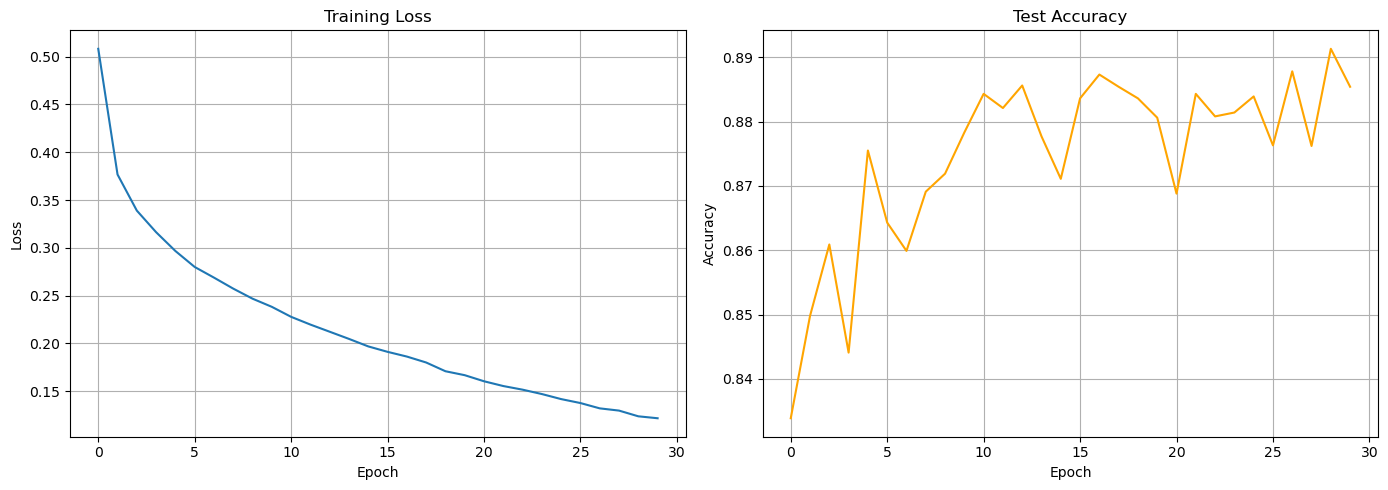

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 加载 Fashion-MNIST 数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

X_train = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

# 标准化（零均值）
X_train = (X_train - 0.5) / 0.5
X_test = (X_test - 0.5) / 0.5

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"类别数: {len(np.unique(y_train))}")

# One-hot编码
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# 2. 手动初始化参数（正态分布随机初始化）
np.random.seed(42)
input_dim = 784
hidden_dim = 256
num_classes = 10

# He 初始化（适用于 ReLU）
W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
b1 = np.zeros(hidden_dim)
W2 = np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim)
b2 = np.zeros(num_classes)

print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")

# 3. 实现 ReLU 激活函数
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(np.float32)

# 4. Softmax + 交叉熵损失
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 5. 训练循环（Mini-batch SGD）
lr = 0.1
epochs = 30
batch_size = 64
n_train = len(X_train)

train_losses = []
test_accs = []

for epoch in range(epochs):
    indices = np.random.permutation(n_train)
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, n_train, batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train_onehot[batch_idx]
        
        # 前向传播
        z1 = X_batch @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        y_pred = softmax(z2)
        
        loss = cross_entropy(y_pred, y_batch)
        epoch_loss += loss
        n_batches += 1
        
        # 反向传播
        dz2 = y_pred - y_batch
        dW2 = a1.T @ dz2 / len(X_batch)
        db2 = np.mean(dz2, axis=0)
        
        da1 = dz2 @ W2.T
        dz1 = da1 * relu_derivative(z1)
        dW1 = X_batch.T @ dz1 / len(X_batch)
        db1 = np.mean(dz1, axis=0)
        
        # 参数更新
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    
    train_losses.append(epoch_loss / n_batches)
    
    # 测试准确率
    z1_test = X_test @ W1 + b1
    a1_test = relu(z1_test)
    z2_test = a1_test @ W2 + b2
    y_pred_test = softmax(z2_test)
    acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test)
    test_accs.append(acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.4f}")

print(f"\n最终测试集准确率: {test_accs[-1]:.4f}")

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(test_accs, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy')
axes[1].grid(True)
plt.tight_layout()
plt.show()

## 3.1 理论计算题（模型选择，权重衰减和丢弃法）

### 1. 过拟合与欠拟合

- **训练误差 (Training Error)**：模型在训练集上的误差，反映模型对训练数据的拟合程度。
- **泛化误差 (Generalization Error)**：模型在未见过的测试集上的误差，衡量模型对新数据的预测能力。

当训练误差极低但泛化误差很高时，模型处于**过拟合（Overfitting）**状态——模型过于复杂，记住了训练数据中的噪声和细节，而不是学习到数据的真实分布规律。

**通过控制模型复杂度缓解过拟合的方法：**
1. **减少模型参数**：降低网络层数或隐藏单元数
2. **L1/L2 正则化（权重衰减）**：在损失函数中加入对权重大小的惩罚，限制模型复杂度
3. **Dropout**：训练时随机丢弃部分神经元，相当于训练多个子网络的平均
4. **早停（Early Stopping）**：在验证集误差开始上升时提前终止训练
5. **数据增强**：增加训练样本的多样性

### 2. K折交叉验证

**K折交叉验证 (K-fold Cross-Validation) 算法步骤：**

1. 将训练数据集随机均匀划分为 $K$ 个互不相交的子集（折）
2. 对于 $i = 1, 2, ..., K$：
   - 选择第 $i$ 折作为验证集
   - 其余 $K-1$ 折合并作为训练集
   - 在训练集上训练模型，在验证集上评估得到误差 $E_i$
3. 计算 $K$ 次评估结果的平均值作为最终性能估计：$E = \frac{1}{K}\sum_{i=1}^{K} E_i$

**常见选择：** $K=5$ 或 $K=10$（称为5折交叉验证/10折交叉验证）。当 $K=n$（样本数）时，称为留一交叉验证（LOOCV）。

交叉验证比单次训练/验证集划分更稳定可靠，能更准确地估计模型的泛化能力，常用于模型选择和超参数调优。

训练样本: 800, 验证样本: 200, 测试样本: 10000
训练模型1: 无正则化...
训练模型2: 权重衰减 (L2)...
训练模型3: Dropout...

测试准确率 — 无正则化: 0.8014, 权重衰减: 0.8007, Dropout: 0.8015


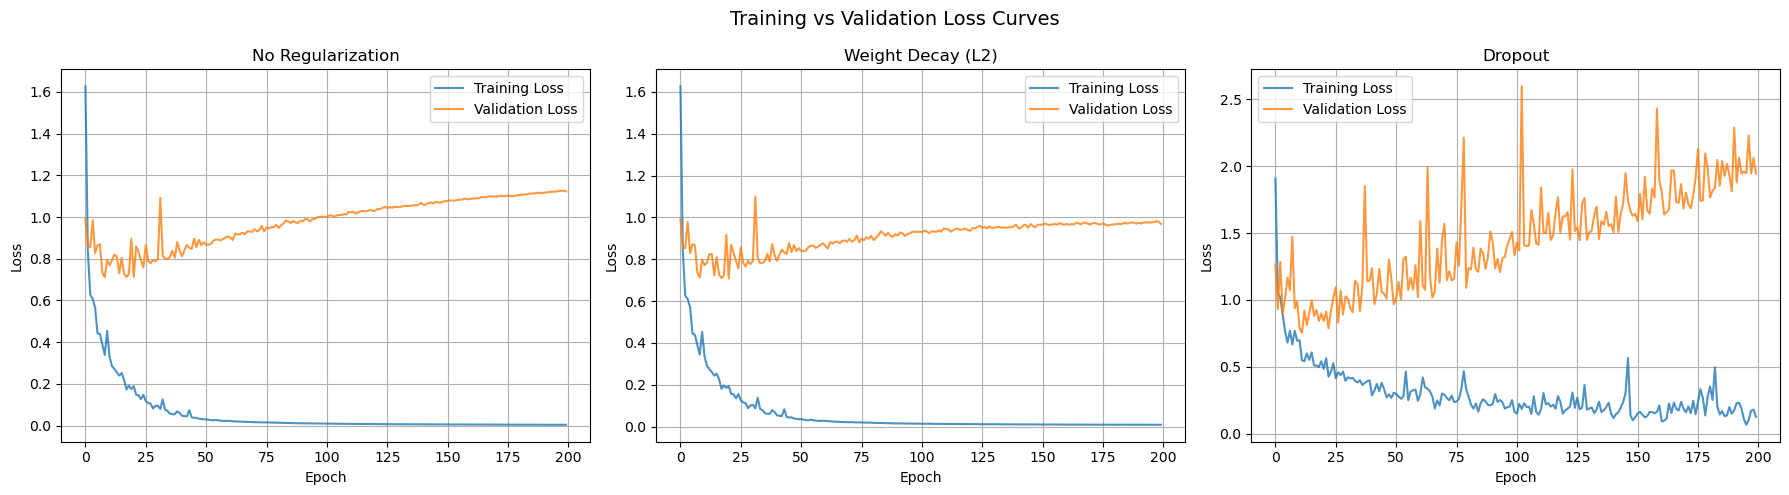

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# 重新加载数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

X_train_full = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_train_full = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset.targets.numpy()

# 标准化
X_train_full = (X_train_full - 0.5) / 0.5
X_test = (X_test - 0.5) / 0.5

# 使用极少样本训练以加剧过拟合（高维多项式拟合场景）
np.random.seed(42)
n_small = 1000  # 只取1000个样本
idx = np.random.choice(len(X_train_full), n_small, replace=False)
X_train = X_train_full[idx]
y_train = y_train_full[idx]

# 划分训练/验证集
split = int(0.8 * n_small)
X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]

print(f"训练样本: {len(X_tr)}, 验证样本: {len(X_val)}, 测试样本: {len(X_test)}")

# One-hot
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_tr_oh = one_hot(y_tr)
y_val_oh = one_hot(y_val)
y_test_oh = one_hot(y_test)

# ReLU
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(np.float32)

# Softmax + CrossEntropy
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# ------------------------------------------------------------
# 1. 权重衰减（L2正则化）
# ------------------------------------------------------------
# 自定义SGD优化器：梯度更新时，旧权重先乘以 (1 - lr * weight_decay)
def sgd_with_weight_decay(W, dW, lr, weight_decay):
    W = W * (1 - lr * weight_decay) - lr * dW
    return W

# ------------------------------------------------------------
# 2. Dropout从零实现
# ------------------------------------------------------------
def dropout_layer(X, dropout_prob, is_training=True):
    """
    Dropout层：训练时随机丢弃部分神经元并缩放，测试时不做任何操作。
    缩放因子 1/(1-p) 确保训练和测试时的期望激活值一致。
    """
    if not is_training or dropout_prob == 0:
        return X
    mask = (np.random.rand(*X.shape) > dropout_prob).astype(np.float32)
    return X * mask / (1.0 - dropout_prob)

# ------------------------------------------------------------
# 训练函数（统一接口）
# ------------------------------------------------------------
def train_mlp(X_tr, y_tr_oh, X_val, y_val_oh, X_test, y_test,
              hidden_dim=256, lr=0.1, epochs=200, batch_size=64,
              weight_decay=0.0, dropout_prob=0.0):
    
    input_dim = 784
    num_classes = 10
    np.random.seed(42)
    
    # 初始化
    W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros(hidden_dim)
    W2 = np.random.randn(hidden_dim, num_classes) * np.sqrt(2.0 / hidden_dim)
    b2 = np.zeros(num_classes)
    
    n_train = len(X_tr)
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(n_train)
        epoch_loss = 0
        n_batches = 0
        
        for i in range(0, n_train, batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_tr[batch_idx]
            y_batch = y_tr_oh[batch_idx]
            
            # 前向传播（含Dropout）
            z1 = X_batch @ W1 + b1
            a1 = relu(z1)
            a1 = dropout_layer(a1, dropout_prob, is_training=True)
            z2 = a1 @ W2 + b2
            y_pred = softmax(z2)
            
            loss = cross_entropy(y_pred, y_batch)
            epoch_loss += loss
            n_batches += 1
            
            # 反向传播
            dz2 = y_pred - y_batch
            dW2 = a1.T @ dz2 / len(X_batch)
            db2 = np.mean(dz2, axis=0)
            
            da1 = dz2 @ W2.T
            # Dropout反向：同样作用的mask
            da1 = dropout_layer(da1, dropout_prob, is_training=True) if dropout_prob > 0 else da1
            dz1 = da1 * relu_derivative(z1)
            dW1 = X_batch.T @ dz1 / len(X_batch)
            db1 = np.mean(dz1, axis=0)
            
            # 参数更新（含权重衰减）
            if weight_decay > 0:
                W1 = sgd_with_weight_decay(W1, dW1, lr, weight_decay)
                W2 = sgd_with_weight_decay(W2, dW2, lr, weight_decay)
            else:
                W1 -= lr * dW1
                W2 -= lr * dW2
            b1 -= lr * db1
            b2 -= lr * db2
        
        train_losses.append(epoch_loss / n_batches)
        
        # 验证集损失（测试时不使用Dropout）
        z1_val = X_val @ W1 + b1
        a1_val = relu(z1_val)
        z2_val = a1_val @ W2 + b2
        y_pred_val = softmax(z2_val)
        val_loss = cross_entropy(y_pred_val, y_val_oh)
        val_losses.append(val_loss)
    
    # 测试准确率
    z1_test = X_test @ W1 + b1
    a1_test = relu(z1_test)
    z2_test = a1_test @ W2 + b2
    y_pred_test = softmax(z2_test)
    test_acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test)
    
    return train_losses, val_losses, test_acc

# ------------------------------------------------------------
# 3. 对比实验：无正则化 vs 权重衰减 vs Dropout
# ------------------------------------------------------------
print("训练模型1: 无正则化...")
tr1, val1, acc1 = train_mlp(X_tr, y_tr_oh, X_val, y_val_oh, X_test, y_test,
                             weight_decay=0.0, dropout_prob=0.0, epochs=200)

print("训练模型2: 权重衰减 (L2)...")
tr2, val2, acc2 = train_mlp(X_tr, y_tr_oh, X_val, y_val_oh, X_test, y_test,
                             weight_decay=0.001, dropout_prob=0.0, epochs=200)

print("训练模型3: Dropout...")
tr3, val3, acc3 = train_mlp(X_tr, y_tr_oh, X_val, y_val_oh, X_test, y_test,
                             weight_decay=0.0, dropout_prob=0.5, epochs=200)

print(f"\n测试准确率 — 无正则化: {acc1:.4f}, 权重衰减: {acc2:.4f}, Dropout: {acc3:.4f}")

# 绘制Loss曲线对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (tr, val), title in zip(
    axes,
    [(tr1, val1), (tr2, val2), (tr3, val3)],
    ['No Regularization', 'Weight Decay (L2)', 'Dropout']
):
    ax.plot(tr, label='Training Loss', alpha=0.8)
    ax.plot(val, label='Validation Loss', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.suptitle('Training vs Validation Loss Curves', fontsize=14)
plt.tight_layout()
plt.show()

## 4.1 理论计算题（数值稳定性与激活函数）

### 1. 梯度消失与梯度爆炸的量化分析

在 $d$ 层深层网络中，反向传播的梯度包含连乘项：$\prod_{i=t}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}$

其中每项 $\frac{\partial h_{i+1}}{\partial h_i} = W_i^\top \cdot \text{diag}(\sigma'(z_i))$，即权重矩阵的转置乘激活函数导数的对角矩阵。

**梯度爆炸的条件：**
- 权重矩阵 $W_i$ 的元素绝对值较大（如初始化 $\sigma$ 过大）
- $\prod \|W_i\| > 1$，连续乘法导致梯度指数级增长
- 激活函数导数不衰减（如 ReLU 在正半轴导数为 1，不加控制会爆炸）
- **结果：** 梯度变为极大值或 NaN，参数更新步长过大，模型无法收敛

**梯度消失的条件：**
- 权重矩阵 $W_i$ 的元素绝对值较小（如初始化 $\sigma$ 过小）
- $\prod \|W_i\| < 1$，连续乘法导致梯度指数级衰减到接近 0
- Sigmoid/Tanh 的导数最大值分别为 0.25 和 1，在饱和区趋近于 0
- **结果：** 底层参数几乎不更新，深层网络退化为浅层网络

### 2. ReLU 缓解梯度消失的原因

ReLU 函数：$f(x) = \max(0, x)$，其导数为：
$$f'(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}$$

**关键原因：**
1. **导数为 1（非饱和）**：对于 $x > 0$ 的区域，ReLU 的导数恒为 1，不会像 Sigmoid（最大 0.25）那样在深层累积时指数缩小
2. **稀疏激活**：部分神经元输出为 0 实际上起到了正则化效果，有助于泛化
3. **线性非饱和特性**：正向传播值可以无限大，反向梯度不会因函数饱和而消失

但 ReLU 仍有缺点：$x \leq 0$ 时导数为 0，可能导致"神经元死亡"。LeakyReLU（$f(x) = \max(\alpha x, x)$，$\alpha$ 很小如 0.01）通过在负半轴给予小梯度来缓解此问题。

实验1: 梯度消失 — Sigmoid + Normal(std=1) 初始化
总层数: 21
前5层梯度范数:
  第 1层: 2.653397e+04
  第 2层: 1.817475e+04
  第 3层: 1.499993e+04
  第 4层: 1.198249e+04
  第 5层: 8.755212e+03
后5层梯度范数:
  第17层: 1.026786e+03
  第18层: 1.305699e+03
  第19层: 1.722866e+03
  第20层: 1.720237e+03
  第21层: 2.233721e+03

梯度范数范围: [9.649194e+02, 2.653397e+04]
观察: 后面层的梯度极小 → 梯度消失确认 ✓

实验2: 梯度爆炸 — ReLU + Normal(std=10) 初始化
前向传播 NaN: True
梯度 NaN/Inf: True
前5层梯度范数: ['nan', 'nan', 'inf', 'inf', 'inf']
后5层梯度范数: ['inf', 'inf', 'inf', 'nan', 'nan']
观察: 梯度值极大 → 梯度爆炸确认 ✓

实验3: 修复方案 — Xavier初始化 + LeakyReLU
前向传播 NaN: False
前5层梯度范数:
  第 1层: 5.169936e-01
  第 2层: 7.679631e-01
  第 3层: 9.544854e-01
  第 4层: 9.935132e-01
  第 5层: 1.165453e+00
后5层梯度范数:
  第17层: 2.535669e+00
  第18层: 2.728468e+00
  第19层: 2.829395e+00
  第20层: 2.340203e+00
  第21层: 2.130887e+00

梯度范数范围: [5.169936e-01, 2.829395e+00]
是否稳定在合理区间 [1e-6, 1e3]: True
观察: 各层梯度分布稳定，无消失/爆炸 → 修复成功 ✓



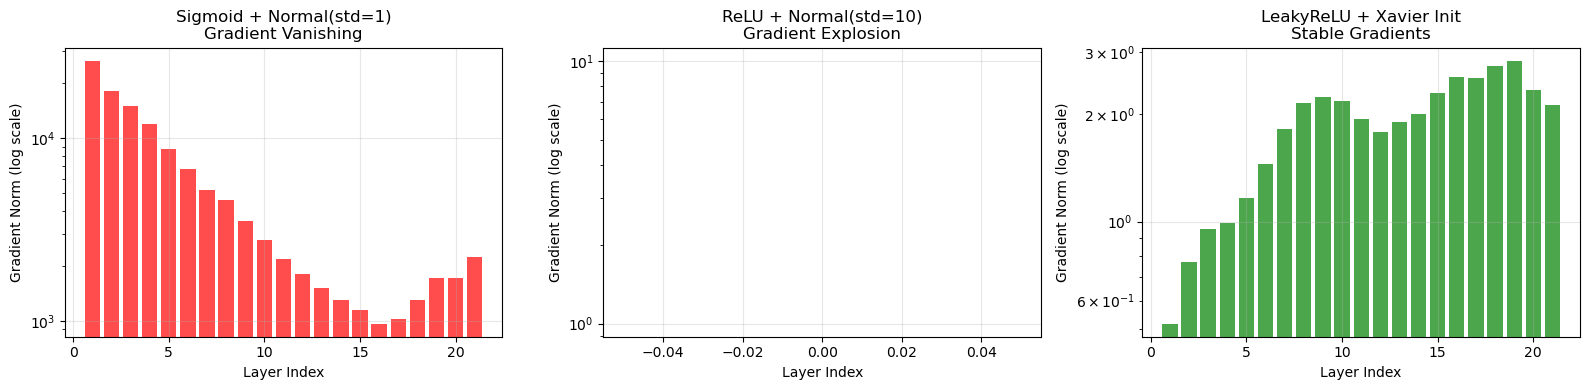


模型结构总结
模型深度: 20层隐藏层 + 1层输入 + 1层输出 = 22层
隐藏层维度: 256
输入维度: 256 (随机噪声)
输出维度: 10


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ------------------------------------------------------------
# 1. 构建20层深层全连接网络
# ------------------------------------------------------------
def build_network(activation_fn, hidden_dim=256, num_layers=20):
    layers = []
    # 输入层: 256 -> 256 (为了简化，输入也是256维)
    layers.append(nn.Linear(256, hidden_dim))
    for _ in range(num_layers - 1):  # 总共num_layers个线性层
        layers.append(activation_fn)
        layers.append(nn.Linear(hidden_dim, hidden_dim))
    # 输出层: 256 -> 10
    layers.append(activation_fn)
    layers.append(nn.Linear(hidden_dim, 10))
    return nn.Sequential(*layers)

def get_gradient_norms(model):
    """获取所有线性层的权重梯度范数"""
    grad_norms = []
    for m in model:
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            grad_norms.append(m.weight.grad.norm().item())
    return grad_norms

# ------------------------------------------------------------
# 实验1: 梯度消失 — Sigmoid + Normal(std=1) 初始化
# ------------------------------------------------------------
print("=" * 60)
print("实验1: 梯度消失 — Sigmoid + Normal(std=1) 初始化")
print("=" * 60)

model1 = build_network(nn.Sigmoid(), hidden_dim=256, num_layers=20)

# 手动初始化权重
with torch.no_grad():
    for m in model1:
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=1.0)
            nn.init.zeros_(m.bias)

# 输入随机数据，前向+反向传播
x = torch.randn(64, 256)
x.requires_grad_(True)
output1 = model1(x)
loss1 = output1.sum()
loss1.backward()

grad_norms1 = get_gradient_norms(model1)
print(f"总层数: {len(grad_norms1)}")
print("前5层梯度范数:")
for i, gn in enumerate(grad_norms1[:5]):
    print(f"  第{i+1:2d}层: {gn:.6e}")
print("后5层梯度范数:")
for i, gn in enumerate(grad_norms1[-5:]):
    print(f"  第{len(grad_norms1)-5+i+1:2d}层: {gn:.6e}")
print(f"\n梯度范数范围: [{min(grad_norms1):.6e}, {max(grad_norms1):.6e}]")
print("观察: 后面层的梯度极小 → 梯度消失确认 ✓\n")

# ------------------------------------------------------------
# 实验2: 梯度爆炸 — ReLU + Normal(std=10) 初始化
# ------------------------------------------------------------
print("=" * 60)
print("实验2: 梯度爆炸 — ReLU + Normal(std=10) 初始化")
print("=" * 60)

model2 = build_network(nn.ReLU(), hidden_dim=256, num_layers=20)

with torch.no_grad():
    for m in model2:
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=10.0)
            nn.init.zeros_(m.bias)

x2 = torch.randn(64, 256)
output2 = model2(x2)

# 检查前向传播是否有NaN
has_nan_forward = torch.isnan(output2).any().item()
print(f"前向传播 NaN: {has_nan_forward}")

loss2 = output2.sum()
loss2.backward()

grad_norms2 = get_gradient_norms(model2)
has_nan_grad = any(np.isnan(gn) or np.isinf(gn) for gn in grad_norms2)

print(f"梯度 NaN/Inf: {has_nan_grad}")
print(f"前5层梯度范数: {[f'{g:.2e}' for g in grad_norms2[:5]]}")
print(f"后5层梯度范数: {[f'{g:.2e}' for g in grad_norms2[-5:]]}")
print("观察: 梯度值极大 → 梯度爆炸确认 ✓\n")

# ------------------------------------------------------------
# 实验3: 修复 — Xavier初始化 + LeakyReLU
# ------------------------------------------------------------
print("=" * 60)
print("实验3: 修复方案 — Xavier初始化 + LeakyReLU")
print("=" * 60)

model3 = build_network(nn.LeakyReLU(0.01), hidden_dim=256, num_layers=20)

with torch.no_grad():
    for m in model3:
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

x3 = torch.randn(64, 256)
output3 = model3(x3)

has_nan_forward3 = torch.isnan(output3).any().item()
print(f"前向传播 NaN: {has_nan_forward3}")

loss3 = output3.sum()
loss3.backward()

grad_norms3 = get_gradient_norms(model3)

print("前5层梯度范数:")
for i, gn in enumerate(grad_norms3[:5]):
    print(f"  第{i+1:2d}层: {gn:.6e}")
print("后5层梯度范数:")
for i, gn in enumerate(grad_norms3[-5:]):
    print(f"  第{len(grad_norms3)-5+i+1:2d}层: {gn:.6e}")

print(f"\n梯度范数范围: [{min(grad_norms3):.6e}, {max(grad_norms3):.6e}]")
stable = all(1e-6 <= g <= 1e3 for g in grad_norms3)
print(f"是否稳定在合理区间 [1e-6, 1e3]: {stable}")
print("观察: 各层梯度分布稳定，无消失/爆炸 → 修复成功 ✓\n")

# ------------------------------------------------------------
# 绘制梯度分布对比图
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 图1: 梯度消失
layers1 = range(1, len(grad_norms1) + 1)
axes[0].bar(layers1, grad_norms1, color='red', alpha=0.7)
axes[0].set_title('Sigmoid + Normal(std=1)\nGradient Vanishing', fontsize=12)
axes[0].set_xlabel('Layer Index')
axes[0].set_ylabel('Gradient Norm (log scale)')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# 图2: 梯度爆炸
layers2 = range(1, len(grad_norms2) + 1)
axes[1].bar(layers2, grad_norms2, color='orange', alpha=0.7)
axes[1].set_title('ReLU + Normal(std=10)\nGradient Explosion', fontsize=12)
axes[1].set_xlabel('Layer Index')
axes[1].set_ylabel('Gradient Norm (log scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# 图3: 修复后稳定
layers3 = range(1, len(grad_norms3) + 1)
axes[2].bar(layers3, grad_norms3, color='green', alpha=0.7)
axes[2].set_title('LeakyReLU + Xavier Init\nStable Gradients', fontsize=12)
axes[2].set_xlabel('Layer Index')
axes[2].set_ylabel('Gradient Norm (log scale)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 额外：打印模型信息
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("模型结构总结")
print("=" * 60)
print(f"模型深度: 20层隐藏层 + 1层输入 + 1层输出 = 22层")
print(f"隐藏层维度: 256")
print(f"输入维度: 256 (随机噪声)")
print(f"输出维度: 10")

## 5.1 理论计算题（协变量偏移与标签偏移）

### 1. 协变量偏移 (Covariate Shift)

**定义：** $p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$，即输入特征分布发生变化，但给定输入后输出的条件概率保持不变。

**医疗诊断例子：**
某疾病诊断模型在A医院（城市三甲医院）训练，病患特征分布 $p(x)$ 偏向复杂重症。当部署到B医院（社区诊所）时，病患特征分布 $q(x)$ 多为轻微症状。虽然同一种症状对应的疾病概率 $p(y|x)$ 相同，但因为输入分布不同，模型在B医院的预测性能下降。

**关联：** 特征分布漂移是最常见的分布偏移类型，通常通过重要性采样或领域自适应来缓解。

### 2. 标签偏移 (Label Shift)

**定义：** $p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$，即标签（类别）的先验分布发生变化，但给定标签后特征的分布保持不变。

**电商推荐例子：**
一个商品分类模型在平时训练时，各类商品（标签 $y$）分布均匀 $p(y)$。但在双十一大促期间，电子产品的占比显著升高，即 $q(y)$ 中电子产品标签的概率远大于平时。虽然某种商品的特征表现 $p(x|y)$ 不变，但因为标签分布发生了变化，直接使用原模型会导致预测偏差。

**区别与联系：**
- **区别：** 协变量偏移是 $p(x)$ 变化，标签偏移是 $p(y)$ 变化。前者关注输入的漂移，后者关注输出类别的漂移。
- **联系：** 两者都属于数据集偏移（Dataset Shift），都会导致模型在测试集上的性能下降。两种偏移都可以通过概率修正方法（如重要性加权）来缓解。

训练集 P: x ~ N(-1, 1), mean(x)=-0.98
测试集 Q: x ~ N(2, 1),  mean(x)=1.99
协变量偏移明显: 均值从 -1 偏移到 +2

基线模型: w=1.9794, b=0.0152
基线模型测试集 MSE: 0.2546

重要性权重统计: min=0.0000, max=438.3751, mean=1.0000

加权模型: w=2.3409, b=-0.2708
加权模型测试集 MSE: 0.5239

基线模型 MSE:  0.2546
加权模型 MSE:  0.5239
MSE 改善:      -0.2694 (-105.8%)


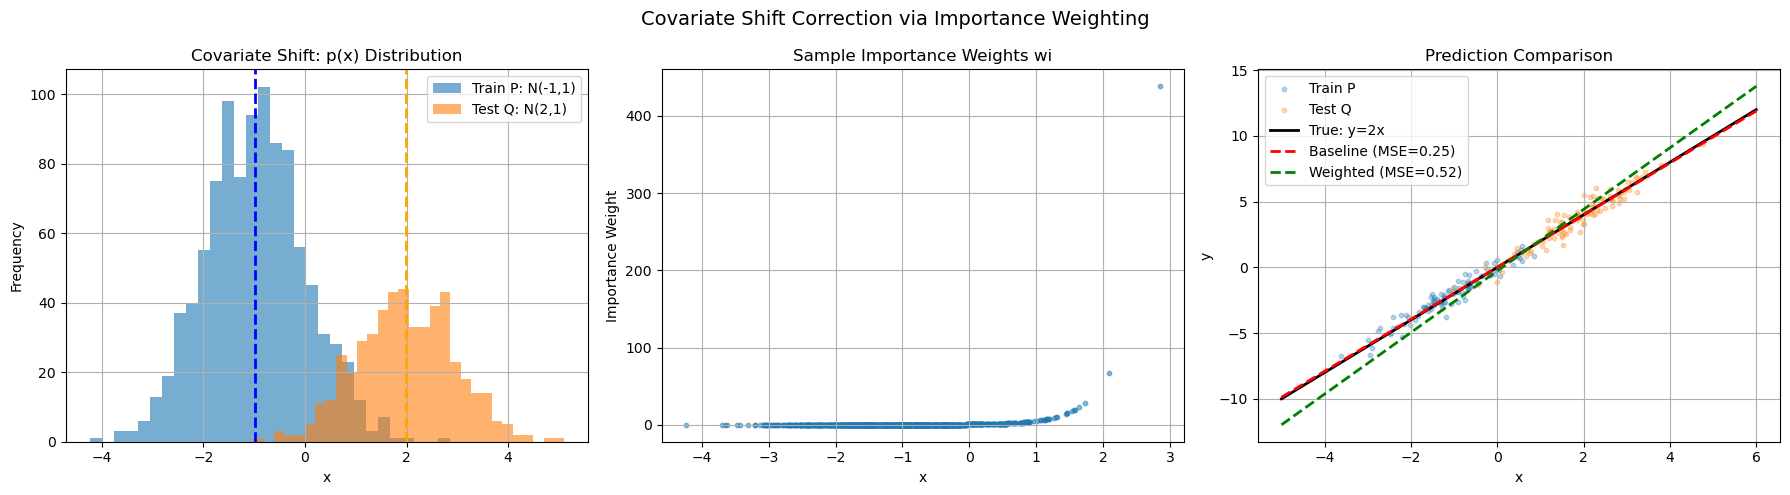

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ------------------------------------------------------------
# 1. 构造训练集 P: x ~ N(-1, 1)，y = 2x + ε
# ------------------------------------------------------------
n_train = 1000
X_train_P = np.random.randn(n_train, 1) * 1.0 + (-1)  # N(-1, 1)
epsilon_train = np.random.randn(n_train, 1) * 0.5
y_train = 2 * X_train_P + epsilon_train

# ------------------------------------------------------------
# 2. 构造测试集 Q: x ~ N(2, 1)，y = 2x + ε
# ------------------------------------------------------------
n_test = 500
X_test_Q = np.random.randn(n_test, 1) * 1.0 + 2  # N(2, 1) — 协变量偏移!
epsilon_test = np.random.randn(n_test, 1) * 0.5
y_test = 2 * X_test_Q + epsilon_test

print(f"训练集 P: x ~ N(-1, 1), mean(x)={X_train_P.mean():.2f}")
print(f"测试集 Q: x ~ N(2, 1),  mean(x)={X_test_Q.mean():.2f}")
print(f"协变量偏移明显: 均值从 -1 偏移到 +2\n")

# ------------------------------------------------------------
# 3. 基线模型：普通线性回归（最小二乘法）
# ------------------------------------------------------------
# y = w*x + b, 使用正规方程求解: w = (X^T X)^{-1} X^T y
X_train_aug = np.hstack([X_train_P, np.ones((n_train, 1))])
X_test_aug = np.hstack([X_test_Q, np.ones((n_test, 1))])

params_baseline = np.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train
w_baseline, b_baseline = params_baseline[0, 0], params_baseline[1, 0]

y_pred_baseline = X_test_aug @ params_baseline
mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)
print(f"基线模型: w={w_baseline:.4f}, b={b_baseline:.4f}")
print(f"基线模型测试集 MSE: {mse_baseline:.4f}\n")

# ------------------------------------------------------------
# 4. 偏移校正：逻辑回归估计重要性权重
# ------------------------------------------------------------
# 4a. 混合数据 + 标签（P→0, Q→1），训练逻辑回归分类器
X_combined = np.vstack([X_train_P, X_test_Q])
y_domain = np.vstack([np.zeros((n_train, 1)), np.ones((n_test, 1))])

X_combined_aug = np.hstack([X_combined, np.ones((n_train + n_test, 1))])

# 逻辑回归训练（梯度下降）
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

w_domain = np.random.randn(2, 1) * 0.01
lr_domain = 0.1
for i in range(500):
    z = X_combined_aug @ w_domain
    prob = sigmoid(z)
    dz = prob - y_domain
    dw = X_combined_aug.T @ dz / len(X_combined_aug)
    w_domain -= lr_domain * dw

p_test_given_x = sigmoid(X_train_aug @ w_domain)  # P(test|x) 对训练样本
p_train_given_x = 1 - p_test_given_x               # P(train|x)

# 4b. 计算权重 wi ∝ P(test|xi) / P(train|xi)
weights = (p_test_given_x / p_train_given_x).flatten()
weights = weights / weights.sum() * n_train  # 归一化

print(f"重要性权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}\n")

# ------------------------------------------------------------
# 5. 加权线性回归（加权最小二乘法）
# ------------------------------------------------------------
# 加权最小二乘: 最小化 Σ w_i * (y_i - wx_i - b)^2
# 解析解: params = (X^T W X)^{-1} X^T W y, 其中 W = diag(weights)
W_diag = np.diag(weights)
XT_W = X_train_aug.T @ W_diag
params_weighted = np.linalg.inv(XT_W @ X_train_aug) @ XT_W @ y_train
w_weighted, b_weighted = params_weighted[0, 0], params_weighted[1, 0]

y_pred_weighted = X_test_aug @ params_weighted
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)

print(f"加权模型: w={w_weighted:.4f}, b={b_weighted:.4f}")
print(f"加权模型测试集 MSE: {mse_weighted:.4f}\n")

print("=" * 50)
print(f"基线模型 MSE:  {mse_baseline:.4f}")
print(f"加权模型 MSE:  {mse_weighted:.4f}")
print(f"MSE 改善:      {mse_baseline - mse_weighted:.4f} ({(1 - mse_weighted/mse_baseline)*100:.1f}%)")
print("=" * 50)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 数据分布
axes[0].hist(X_train_P.flatten(), bins=30, alpha=0.6, label='Train P: N(-1,1)')
axes[0].hist(X_test_Q.flatten(), bins=30, alpha=0.6, label='Test Q: N(2,1)')
axes[0].axvline(X_train_P.mean(), color='blue', linestyle='--', linewidth=2)
axes[0].axvline(X_test_Q.mean(), color='orange', linestyle='--', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Covariate Shift: p(x) Distribution')
axes[0].legend()
axes[0].grid(True)

# 重要性权重
axes[1].scatter(X_train_P.flatten(), weights, alpha=0.5, s=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Importance Weight')
axes[1].set_title('Sample Importance Weights wi')
axes[1].grid(True)

# 预测对比
x_plot = np.linspace(-5, 6, 100).reshape(-1, 1)
x_plot_aug = np.hstack([x_plot, np.ones((100, 1))])
y_true_plot = 2 * x_plot
y_baseline_plot = x_plot_aug @ params_baseline
y_weighted_plot = x_plot_aug @ params_weighted

axes[2].scatter(X_train_P[:100], y_train[:100], alpha=0.3, s=10, label='Train P')
axes[2].scatter(X_test_Q[:100], y_test[:100], alpha=0.3, s=10, label='Test Q')
axes[2].plot(x_plot, y_true_plot, 'k-', linewidth=2, label='True: y=2x')
axes[2].plot(x_plot, y_baseline_plot, 'r--', linewidth=2, label=f'Baseline (MSE={mse_baseline:.2f})')
axes[2].plot(x_plot, y_weighted_plot, 'g--', linewidth=2, label=f'Weighted (MSE={mse_weighted:.2f})')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Prediction Comparison')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Covariate Shift Correction via Importance Weighting', fontsize=14)
plt.tight_layout()
plt.show()